<table>
<tr>
<td><img src="https://www.institutobme.es/dam/layout/bme-logo.svg" width="150"></td>
<td><table><tr><td><h1> Introducción a la ciencia de datos con Python</h1></td></tr>
           <tr><td><h3>Rafael Caballero Roldán</h3></td></tr></table></td>

</tr>
</table>

# Ejemplo selección de carteras


Objetivo: a partir de una lsita inicial de valores bursátiles (en este caso ETFs -UCITS-) queremos simular la creación de 10000 posibles carteras/portfolios para evaluar la ganancia y la volatilidad de cada uno de ellos.

Empezamos con unas funciones básicas para descargar datos y generar las carteras

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm

# para mostrar resultados "bonitos"
from html import escape
from IPython.display import display, HTML
import plotly.graph_objects as go

def descargar_tickers(tickers, fecha_inicial, umbral_validez=0.8):

    #tickers = df["Ticker"].dropna().unique().tolist()

    data = yf.download(
        tickers.tolist(),
        start=fecha_inicial,
        auto_adjust=True,
        progress=False,
        group_by="column",
    )

    if len(tickers) == 1:
        # Con un solo ticker las columnas no son MultiIndex
        precios = data[["Close"]].rename(columns={"Close": tickers[0]})
        volumenes = data[["Volume"]].rename(columns={"Volume": tickers[0]})
    else:
        precios = data["Close"]
        volumenes = data["Volume"]

    fraccion_valida = precios.notna().mean()
    validos = fraccion_valida[fraccion_valida >= umbral_validez].index

    precios = precios[validos]
    volumenes = volumenes[validos]

    return precios, volumenes


def carteras(df_close, n, m, freq=252, seed=None):
    """
    Genera carteras aleatorias seleccionando m columnas del dataframe de precios.

    Parámetros
    ----------
    df_close : pd.DataFrame
        DataFrame con precios de cierre diarios. Una columna por activo.
    n : int
        Número de carteras a generar.
    m : int
        Número de activos por cartera.
    freq : int
        Frecuencia anualizadora. 252 para datos diarios.
    seed : int, opcional
        Semilla para reproducibilidad.

    Devuelve
    --------
    lista_carteras : list
        Lista de carteras generadas. Cada cartera es una lista de tickers.
    resultados : pd.DataFrame
        DataFrame con rentabilidad y volatilidad de cada cartera.
    """

    if m > df_close.shape[1]:
        raise ValueError("m no puede ser mayor que el número de columnas del dataframe.")

    rng = np.random.default_rng(seed)

    # Rentabilidades diarias
    returns = df_close.pct_change().dropna(how="all")

    columnas = returns.columns.to_numpy()

    lista_carteras = []
    rentabilidades = []
    volatilidades = []

    for _ in tqdm(range(n), desc="Generando carteras"):
        # Selección aleatoria de m activos sin repetición
        cartera = rng.choice(columnas, size=m, replace=False).tolist()

        # Rentabilidad diaria de la cartera equiponderada
        ret_cartera = returns[cartera].mean(axis=1)

        # Rentabilidad anualizada
        rent_anual = ret_cartera.mean() * freq

        # Volatilidad anualizada
        vol_anual = ret_cartera.std() * np.sqrt(freq)

        lista_carteras.append(cartera)
        rentabilidades.append(rent_anual)
        volatilidades.append(vol_anual)

    return lista_carteras,  rentabilidades,volatilidades


def muestra(df, cartera, rentabilidad, volatilidad, i):
    

    columnas_necesarias = {
        "Ticker",
        "Nombre",
        "Categoría",
        "Índice",
        "Acumulación / distribución",
        "Bolsa",
        "Moneda",
    }

    columnas_faltantes = columnas_necesarias - set(df.columns)

    if columnas_faltantes:
        raise ValueError(
            "Faltan estas columnas en df: "
            + ", ".join(sorted(columnas_faltantes))
        )

    tickers = list(cartera[i])

    if len(tickers) == 0:
        raise ValueError("La cartera seleccionada no contiene activos.")

    rent = float(rentabilidad[i])
    vol = float(volatilidad[i])

    # ---------------------------------------------------------
    # Información de los ETF
    # ---------------------------------------------------------
    informacion = (
        df.drop_duplicates(subset="Ticker")
          .set_index("Ticker")
          .reindex(tickers)
          .reset_index()
    )

    informacion["Peso"] = 100 / len(tickers)

    columnas_mostrar = [
        "Ticker",
        "Nombre",
        "Categoría",
        "Índice",
        "Acumulación / distribución",
        "Bolsa",
        "Moneda",
        "Peso",
    ]

    informacion = informacion[columnas_mostrar]

    # Valores que no se hayan podido encontrar en el Excel
    columnas_texto = informacion.columns.drop("Peso")
    informacion[columnas_texto] = (
        informacion[columnas_texto].fillna("No disponible")
    )

    # ---------------------------------------------------------
    # Distribución por categorías
    # ---------------------------------------------------------
    categorias = (
        informacion["Categoría"]
        .value_counts()
        .rename_axis("Categoría")
        .reset_index(name="Número")
    )

    categorias["Peso"] = categorias["Número"] / len(tickers) * 100

    barras_categorias = ""

    for _, fila in categorias.iterrows():
        categoria = escape(str(fila["Categoría"]))
        peso = float(fila["Peso"])

        barras_categorias += f"""
        <div class="categoria-fila">
            <div class="categoria-nombre">{categoria}</div>

            <div class="categoria-fondo">
                <div class="categoria-barra"
                     style="width: {peso:.2f}%;">
                </div>
            </div>

            <div class="categoria-peso">{peso:.0f}%</div>
        </div>
        """

    # ---------------------------------------------------------
    # Filas de la tabla
    # ---------------------------------------------------------
    filas_tabla = ""

    for _, fila in informacion.iterrows():

        ticker = escape(str(fila["Ticker"]))
        nombre = escape(str(fila["Nombre"]))
        categoria = escape(str(fila["Categoría"]))
        indice = escape(str(fila["Índice"]))
        reparto = escape(str(fila["Acumulación / distribución"]))
        bolsa = escape(str(fila["Bolsa"]))
        moneda = escape(str(fila["Moneda"]))
        peso = float(fila["Peso"])

        filas_tabla += f"""
        <tr>
            <td><span class="ticker">{ticker}</span></td>

            <td class="nombre-etf">{nombre}</td>

            <td>
                <span class="categoria-etiqueta">
                    {categoria}
                </span>
            </td>

            <td>{indice}</td>
            <td class="centrado">{reparto}</td>
            <td>{bolsa}</td>
            <td class="centrado">{moneda}</td>
            <td class="peso">{peso:.1f}%</td>
        </tr>
        """

    clase_rentabilidad = "positiva" if rent >= 0 else "negativa"

    # ---------------------------------------------------------
    # Documento HTML
    # ---------------------------------------------------------
    html = f"""
    <style>
        .cartera-contenedor {{
            font-family: Inter, "Segoe UI", Arial, sans-serif;
            max-width: 1200px;
            margin: 15px auto;
            color: #172033;
        }}

        .cartera-cabecera {{
            padding: 28px 32px;
            border-radius: 18px;
            background:
                linear-gradient(120deg, #071c33 0%,
                                      #0d4261 55%,
                                      #008c9e 100%);
            color: white;
            box-shadow: 0 12px 30px rgba(7, 28, 51, 0.20);
            margin-bottom: 18px;
        }}

        .cartera-cabecera h1 {{
            margin: 0;
            font-size: 29px;
            font-weight: 750;
            letter-spacing: -0.5px;
        }}

        .cartera-cabecera p {{
            margin: 7px 0 0 0;
            color: #ccebf0;
            font-size: 14px;
        }}

        .metricas {{
            display: grid;
            grid-template-columns: repeat(3, minmax(160px, 1fr));
            gap: 14px;
            margin-top: 24px;
        }}

        .metrica {{
            padding: 16px 18px;
            border: 1px solid rgba(255, 255, 255, 0.18);
            border-radius: 13px;
            background: rgba(255, 255, 255, 0.10);
            backdrop-filter: blur(5px);
        }}

        .metrica-titulo {{
            font-size: 12px;
            text-transform: uppercase;
            letter-spacing: 0.8px;
            color: #ccebf0;
            margin-bottom: 6px;
        }}

        .metrica-valor {{
            font-size: 27px;
            font-weight: 750;
            color: white;
        }}

        .metrica-valor.positiva {{
            color: #72f1b8;
        }}

        .metrica-valor.negativa {{
            color: #ff9d9d;
        }}

        .panel {{
            background: white;
            border: 1px solid #e5eaf0;
            border-radius: 16px;
            padding: 22px 25px;
            margin-bottom: 18px;
            box-shadow: 0 5px 18px rgba(19, 41, 68, 0.07);
        }}

        .panel h2 {{
            margin: 0 0 18px 0;
            font-size: 18px;
            color: #12334d;
        }}

        .categoria-fila {{
            display: grid;
            grid-template-columns: minmax(180px, 2fr) 5fr 55px;
            gap: 12px;
            align-items: center;
            margin: 10px 0;
            font-size: 13px;
        }}

        .categoria-nombre {{
            font-weight: 600;
            color: #38475a;
        }}

        .categoria-fondo {{
            height: 11px;
            overflow: hidden;
            border-radius: 10px;
            background: #edf2f5;
        }}

        .categoria-barra {{
            height: 100%;
            min-width: 5px;
            border-radius: 10px;
            background: linear-gradient(90deg, #00a5b5, #ffc83d);
        }}

        .categoria-peso {{
            font-weight: 700;
            color: #087d8b;
            text-align: right;
        }}

        .tabla-contenedor {{
            overflow-x: auto;
            border-radius: 12px;
            border: 1px solid #e1e7ec;
        }}

        .tabla-cartera {{
            width: 100%;
            min-width: 1050px;
            border-collapse: collapse;
            font-size: 13px;
            background: white;
        }}

        .tabla-cartera thead th {{
            padding: 13px 12px;
            background: #eef6f7;
            color: #174357;
            border-bottom: 2px solid #cddfe2;
            text-align: left;
            font-size: 11px;
            text-transform: uppercase;
            letter-spacing: 0.45px;
        }}

        .tabla-cartera tbody td {{
            padding: 13px 12px;
            border-bottom: 1px solid #edf0f3;
            vertical-align: middle;
        }}

        .tabla-cartera tbody tr:nth-child(even) {{
            background: #fafcfd;
        }}

        .tabla-cartera tbody tr:hover {{
            background: #f0fafb;
        }}

        .ticker {{
            display: inline-block;
            padding: 5px 8px;
            border-radius: 7px;
            background: #12334d;
            color: white;
            font-weight: 700;
            letter-spacing: 0.3px;
            white-space: nowrap;
        }}

        .categoria-etiqueta {{
            display: inline-block;
            max-width: 180px;
            padding: 5px 8px;
            border-radius: 10px;
            background: #e1f6f5;
            color: #087d83;
            font-size: 11px;
            font-weight: 650;
        }}

        .nombre-etf {{
            min-width: 250px;
            font-weight: 550;
            color: #263849;
        }}

        .centrado {{
            text-align: center;
        }}

        .peso {{
            color: #087d83;
            font-weight: 750;
            text-align: right;
        }}

        .nota {{
            margin: 14px 2px 0 2px;
            font-size: 11px;
            color: #718096;
        }}

        @media (max-width: 700px) {{
            .metricas {{
                grid-template-columns: 1fr;
            }}

            .categoria-fila {{
                grid-template-columns: 1fr;
            }}

            .categoria-peso {{
                text-align: left;
            }}
        }}
    </style>

    <div class="cartera-contenedor">

        <div class="cartera-cabecera">
            <h1>Cartera #{i + 1}</h1>

            <p>
                Selección equiponderada de ETF UCITS
            </p>

            <div class="metricas">

                <div class="metrica">
                    <div class="metrica-titulo">
                        Rentabilidad anualizada
                    </div>

                    <div class="metrica-valor {clase_rentabilidad}">
                        {rent:.2%}
                    </div>
                </div>

                <div class="metrica">
                    <div class="metrica-titulo">
                        Volatilidad anualizada
                    </div>

                    <div class="metrica-valor">
                        {vol:.2%}
                    </div>
                </div>

                <div class="metrica">
                    <div class="metrica-titulo">
                        Número de ETF
                    </div>

                    <div class="metrica-valor">
                        {len(tickers)}
                    </div>
                </div>

            </div>
        </div>

        <div class="panel">
            <h2>Distribución por categorías</h2>

            {barras_categorias}
        </div>

        <div class="panel">
            <h2>Composición de la cartera</h2>

            <div class="tabla-contenedor">
                <table class="tabla-cartera">
                    <thead>
                        <tr>
                            <th>Ticker</th>
                            <th>ETF</th>
                            <th>Categoría</th>
                            <th>Índice</th>
                            <th>Política</th>
                            <th>Bolsa</th>
                            <th>Moneda</th>
                            <th>Peso</th>
                        </tr>
                    </thead>

                    <tbody>
                        {filas_tabla}
                    </tbody>
                </table>
            </div>

            <div class="nota">
                Rentabilidad y volatilidad anualizadas a partir de
                datos históricos. Cada ETF tiene el mismo peso dentro
                de la cartera.
            </div>
        </div>

    </div>
    """

    display(HTML(html))


def grafica_carteras(df_carteras):

    datos = df_carteras.dropna(
        subset=["vol", "rent"]
    ).copy()

    # Índice original: coincide con el i utilizado por muestra(...)
    datos["numero_cartera"] = datos.index

    datos["vol_pct"] = datos["vol"] * 100
    datos["rent_pct"] = datos["rent"] * 100

    datos["activos"] = datos["cartera"].apply(
        lambda activos: "<br>".join(
            str(activo) for activo in activos
        )
    )

    # ---------------------------------------------------------
    # Regresión lineal
    # ---------------------------------------------------------
    pendiente, intercepto = np.polyfit(
        datos["vol_pct"],
        datos["rent_pct"],
        deg=1
    )

    rentabilidad_estimada = (
        intercepto
        + pendiente * datos["vol_pct"]
    )

    residuos = (
        datos["rent_pct"]
        - rentabilidad_estimada
    )

    ss_res = np.sum(residuos**2)

    ss_tot = np.sum(
        (
            datos["rent_pct"]
            - datos["rent_pct"].mean()
        )**2
    )

    r2 = 1 - ss_res / ss_tot

    correlacion = datos["vol_pct"].corr(
        datos["rent_pct"]
    )

    x_linea = np.linspace(
        datos["vol_pct"].min(),
        datos["vol_pct"].max(),
        200
    )

    y_linea = (
        intercepto
        + pendiente * x_linea
    )

    # ---------------------------------------------------------
    # Gráfica
    # ---------------------------------------------------------
    fig = go.Figure()

    # Puntos: utilizamos Scatter, no Scattergl
    fig.add_trace(
        go.Scatter(
            x=datos["vol_pct"],
            y=datos["rent_pct"],
            mode="markers",
            name="Carteras simuladas",

            customdata=datos[
                ["numero_cartera", "activos"]
            ].to_numpy(),

            marker=dict(
                size=7,
                opacity=0.50,
                color=datos["rent_pct"],
                colorscale="Viridis",
                showscale=True,
                colorbar=dict(
                    title="Rentabilidad<br>anual (%)"
                )
            ),

            hovertemplate=(
                "<b>Cartera para muestra: "
                "%{customdata[0]}</b><br>"
                "<br>"
                "<b>Activos</b><br>"
                "%{customdata[1]}"
                "<br><br>"
                "<b>Volatilidad:</b> %{x:.2f}%<br>"
                "<b>Rentabilidad:</b> %{y:.2f}%"
                "<extra></extra>"
            )
        )
    )

    # Se añade después para que quede por encima
    fig.add_trace(
        go.Scatter(
            x=x_linea,
            y=y_linea,
            mode="lines",
            name="Tendencia lineal",

            line=dict(
                width=5,
                dash="dash",
                color="#F97316"
            ),

            hovertemplate=(
                "<b>Línea de tendencia</b><br>"
                "Volatilidad: %{x:.2f}%<br>"
                "Rentabilidad estimada: %{y:.2f}%"
                "<extra></extra>"
            )
        )
    )

    # ---------------------------------------------------------
    # Cartera de máxima rentabilidad
    # ---------------------------------------------------------
    i_max = datos["rent_pct"].idxmax()

    fig.add_trace(
        go.Scatter(
            x=[datos.loc[i_max, "vol_pct"]],
            y=[datos.loc[i_max, "rent_pct"]],
            mode="markers",
            name="Máxima rentabilidad",

            customdata=[[i_max]],

            marker=dict(
                size=18,
                symbol="star",
                color="#EF4444",
                line=dict(
                    color="white",
                    width=2
                )
            ),

            hovertemplate=(
                "<b>Cartera de máxima rentabilidad</b><br>"
                "Cartera para muestra: %{customdata[0]}<br>"
                "Volatilidad: %{x:.2f}%<br>"
                "Rentabilidad: %{y:.2f}%"
                "<extra></extra>"
            )
        )
    )

    texto_modelo = (
        "<b>Tendencia lineal</b><br>"
        f"Rentabilidad = {intercepto:.2f} "
        f"+ {pendiente:.2f} × Volatilidad<br>"
        f"Pendiente: {pendiente:.3f}<br>"
        f"Intercepto: {intercepto:.3f}<br>"
        f"R²: {r2:.3f}<br>"
        f"Correlación: {correlacion:.3f}<br>"
        f"Número de carteras: {len(datos):,}"
    )

    fig.add_annotation(
        x=0.02,
        y=0.98,
        xref="paper",
        yref="paper",
        text=texto_modelo,
        showarrow=False,
        align="left",
        xanchor="left",
        yanchor="top",

        bgcolor="rgba(255,255,255,0.94)",
        bordercolor="#CBD5E1",
        borderwidth=1,
        borderpad=12,

        font=dict(
            size=13,
            color="#1E293B"
        )
    )

    fig.update_layout(
        title=dict(
            text=(
                "<b>Rentabilidad y riesgo de las "
                "carteras simuladas</b>"
                "<br>"
                "<sup>Cada punto representa una "
                "cartera equiponderada</sup>"
            ),
            x=0.5,
            xanchor="center"
        ),

        template="plotly_white",
        width=1050,
        height=680,

        xaxis=dict(
            title="<b>Volatilidad anualizada</b>",
            ticksuffix="%",
            gridcolor="rgba(148,163,184,0.25)",
            zeroline=False
        ),

        yaxis=dict(
            title="<b>Rentabilidad anualizada</b>",
            ticksuffix="%",
            gridcolor="rgba(148,163,184,0.25)",
            zeroline=False
        ),

        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),

        hoverlabel=dict(
            bgcolor="white",
            font_size=13
        ),

        margin=dict(
            l=80,
            r=80,
            t=120,
            b=80
        )
    )

    fig.show()

    return {
        "pendiente": pendiente,
        "intercepto": intercepto,
        "r2": r2,
        "correlacion": correlacion
    }

### Carga de datos

Utilizamos la librería de Yahoo finance para descargar valores bursátiles

In [2]:
import pandas as pd

url = "https://github.com/RafaelCaballero/tdm/raw/refs/heads/master/datos/etf_ucits.xlsx"

df = pd.read_excel(url)

df_close, df_volume = descargar_tickers(df["Ticker"],"2023-01-01")

df_close.to_excel("close.xlsx")
df_close

Ticker,AGGH.AS,ANX.MI,C3M.PA,CAC.PA,CEUU.AS,CNDX.AS,CNYA.DE,CW8.PA,D5BG.DE,DBX5.DE,...,XAIN.DE,XCS3.DE,XCS4.DE,XCS6.DE,XEON.DE,XESP.DE,ZPRR.DE,ZPRS.DE,ZPRV.DE,ZPRX.DE
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-02,4.5516,117.860001,115.400002,59.659805,6.503,592.599976,NaN,383.745514,141.139999,40.320000,...,14.446,9.957,22.735001,13.878,135.119003,24.120001,47.500000,81.680000,49.130001,41.450001
2023-01-03,4.5691,115.570000,115.400002,59.999352,6.573,581.599976,4.5620,380.014709,141.104996,40.720001,...,14.504,9.834,23.340000,14.352,135.141006,24.160000,46.744999,81.150002,48.654999,41.695000
2023-01-04,4.5712,116.480003,115.375000,61.293316,6.709,583.700012,4.5835,383.486694,141.729996,40.700001,...,14.372,9.869,23.590000,14.890,135.167999,24.575001,47.314999,81.879997,49.400002,42.439999
2023-01-05,4.5800,115.190002,115.379997,61.164841,6.699,580.799988,4.6745,381.183807,141.330002,40.980000,...,14.022,9.949,23.350000,15.128,135.175003,24.709999,46.895000,81.430000,49.125000,42.544998
2023-01-06,4.5661,115.860001,115.360001,62.045826,6.778,583.900024,4.7245,384.860199,142.085007,41.650002,...,14.090,9.937,23.705000,15.142,135.173004,25.025000,47.570000,82.480003,49.974998,43.130001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,4.9130,285.700012,126.504997,82.750000,12.152,1434.199951,5.2500,658.041321,163.399994,125.099998,...,7.341,12.370,25.340000,15.488,149.350006,58.540001,72.820000,124.660004,77.690002,65.980003
2026-06-12,4.9285,293.500000,126.480003,84.180000,12.394,1471.000000,5.3300,668.464478,163.679993,128.179993,...,7.542,12.406,25.870001,15.722,149.365005,60.200001,74.610001,127.739998,79.260002,67.279999
2026-06-15,4.9345,301.209991,126.514999,84.529999,12.466,1509.400024,5.4450,676.588928,163.934998,132.100006,...,7.930,12.546,25.850000,15.896,149.367996,61.029999,74.860001,128.440002,79.169998,67.580002


## Generación de carteras

Generamos 10000 portfolios al azar, cada uno formado por 10 valores de los descargados. La función `carteras`nos devuelve además de las 10000 carteras la rentabilidad y la volatilidad

In [3]:
cartera,rentabilidad, volatilidad = carteras(df_close, 10000, 10)

Generando carteras: 100%|██████████| 10000/10000 [00:04<00:00, 2207.62it/s]


In [4]:
muestra(df,cartera, rentabilidad, volatilidad,5000) # la cartera 2

Ticker,ETF,Categoría,Índice,Política,Bolsa,Moneda,Peso
DBX5.DE,Xtrackers MSCI Taiwan UCITS ETF 1C,ASIA / PACÍFICO,MSCI Taiwan,Acc,Xetra,USD,10.0%
IQQW.DE,iShares MSCI World UCITS ETF (Dist),RENTA VARIABLE GLOBAL / CORE,MSCI World,Dist,Xetra,EUR,10.0%
D5BG.DE,Xtrackers II EUR Corporate Bond UCITS ETF,BONOS / RENTA FIJA CORE,EUR Corp,N/D,Xetra,EUR,10.0%
IWMO.MI,iShares Edge MSCI World Momentum Factor UCITS ETF,FACTORES (WORLD),MSCI World Momentum Factor,N/D,Borsa Italiana,EUR,10.0%
EMBE.MI,iShares J.P. Morgan $ EM Bond EUR Hedged UCITS ETF,BONOS / RENTA FIJA CORE,EM USD Bonds (EUR Hedged),N/D,Borsa Italiana,EUR,10.0%
SXR0.DE,iShares Edge MSCI World Min Vol EUR Hedged UCITS ETF (Acc),FACTORES (WORLD),MSCI World Min Vol (EUR Hedged),Acc,Xetra,EUR,10.0%
XAIN.DE,Xtrackers MSCI Indonesia Swap UCITS ETF 1C,CHINA / INDIA,MSCI Indonesia,Acc,Xetra,EUR,10.0%
IEAC.AS,iShares Core € Corp Bond UCITS ETF,BONOS / RENTA FIJA CORE,Euro Corp IG,N/D,Euronext Amsterdam,EUR,10.0%
EUNJ.DE,iShares MSCI Pacific ex-Japan UCITS ETF (Dist),ASIA / PACÍFICO,MSCI Pacific ex Japan,Dist,Xetra,EUR,10.0%
XEON.DE,Xtrackers II EUR Overnight Rate Swap UCITS ETF,CASH / OVERNIGHT (muy usado como “parking”),€STR/Overnight (swap),N/D,Xetra,EUR,10.0%


# Rentabilidd y volatilidad media y máxima

In [5]:
# dataframe con todas las carteras
df_carteras = pd.DataFrame({"cartera":cartera,"rent":rentabilidad,"vol":volatilidad})
df_carteras

,cartera,rent,vol
0,"[IUSN.DE, EUN5.DE, DBX5.DE, VWRL.AS, DBX7.DE, ...",0.145919,0.154430
1,"[IWVL.MI, CAC.PA, IEAC.AS, QDV5.DE, CEUU.AS, Z...",0.129221,0.101780
2,"[IS3N.DE, VWCE.DE, VAGF.DE, EUN5.DE, IEAC.AS, ...",0.100548,0.084145
3,"[EUNK.DE, IQQ6.DE, CNYA.DE, IBGS.AS, EIMI.MI, ...",0.094350,0.144864
4,"[IWQU.MI, XCS6.DE, EXXT.DE, EUN5.DE, IUSQ.DE, ...",0.139451,0.106964
...,...,...,...
9995,"[SXR0.DE, SXR8.DE, EQQQ.MI, IBCI.AS, EXXT.DE, ...",0.185804,0.137382
9996,"[CNYA.DE, CNDX.AS, VAGF.DE, ANX.MI, D5BG.DE, X...",0.130872,0.113428
9997,"[CAC.PA, ZPRS.DE, D5BG.DE, EUNH.DE, IQQE.DE, C...",0.148065,0.105040
9998,"[ICHN.AS, EUNN.DE, IPRP.AS, IEAC.AS, VECP.AS, ...",0.123150,0.098579


In [6]:
print(f'Rentabilidad media anual: {df_carteras["rent"].mean():.2%}')
print(f'Volatilidad media anual: {df_carteras["vol"].mean():.2%}')

Rentabilidad media anual: 12.93%
Volatilidad media anual: 11.20%


In [7]:
i_max = df_carteras["rent"].idxmax()

muestra(df,cartera, rentabilidad, volatilidad,i_max)

Ticker,ETF,Categoría,Índice,Política,Bolsa,Moneda,Peso
IQQJ.DE,iShares MSCI Japan UCITS ETF (Dist),ASIA / PACÍFICO,MSCI Japan,Dist,Xetra,EUR,10.0%
ANX.MI,Amundi Nasdaq-100 (swap) UCITS ETF,NASDAQ 100,Nasdaq-100,N/D,Borsa Italiana,EUR,10.0%
CNDX.AS,iShares NASDAQ 100 UCITS ETF (Acc),NASDAQ 100,Nasdaq-100,Acc,Euronext Amsterdam,EUR,10.0%
EXS1.DE,iShares Core DAX UCITS ETF,PAÍSES (Europa),DAX,N/D,Xetra,EUR,10.0%
EXXT.DE,iShares Nasdaq 100 UCITS ETF (DE),NASDAQ 100,Nasdaq-100,N/D,Xetra,EUR,10.0%
ZPRR.DE,SPDR Russell 2000 US Small Cap UCITS ETF,SPDR small/value (ejemplos populares),Russell 2000,N/D,Xetra,EUR,10.0%
SPPW.DE,SPDR MSCI World UCITS ETF,RENTA VARIABLE GLOBAL / CORE,MSCI World,N/D,Xetra,EUR,10.0%
ZPRS.DE,SPDR MSCI World Small Cap UCITS ETF,SMALL CAPS / INMOBILIARIO,MSCI World Small Cap,N/D,Xetra,EUR,10.0%
DBX8.DE,Xtrackers MSCI Korea UCITS ETF 1C,ASIA / PACÍFICO,MSCI Korea,Acc,Xetra,USD,10.0%
EIMI.MI,iShares Core MSCI EM IMI UCITS ETF (Acc),EMERGENTES,MSCI EM IMI,Acc,Borsa Italiana,EUR,10.0%


### Mejor rentabilidad dada una volatilidad máxima 

In [9]:
volatilidad_maxima = 0.14  # 10 %

# Carteras que cumplen la restricción de volatilidad
filtro = df_carteras["vol"] <= volatilidad_maxima
df_maxvolatilidad = df_carteras[filtro]

if df_maxvolatilidad.empty:
    print("No hay ninguna cartera con esa volatilidad máxima.")
else:
    # Índice original de la cartera con mayor rentabilidad
    print(f"Carteras que cumplen la condición: {len(df_maxvolatilidad)} de {len(df_carteras)}")
    i_max = df_maxvolatilidad["rent"].idxmax()

    muestra(        df,        cartera,        rentabilidad,        volatilidad,        i_max    )

Carteras que cumplen la condición: 8790 de 10000


Ticker,ETF,Categoría,Índice,Política,Bolsa,Moneda,Peso
ERNE.AS,iShares € Ultrashort Bond UCITS ETF,BONOS / RENTA FIJA CORE,EUR Ultrashort,N/D,Euronext Amsterdam,EUR,10.0%
IQQJ.DE,iShares MSCI Japan UCITS ETF (Dist),ASIA / PACÍFICO,MSCI Japan,Dist,Xetra,EUR,10.0%
XESP.DE,Xtrackers Spain UCITS ETF (Solactive Spain 40),PAÍSES (Europa),Solactive Spain 40,N/D,Xetra,EUR,10.0%
ZPRS.DE,SPDR MSCI World Small Cap UCITS ETF,SMALL CAPS / INMOBILIARIO,MSCI World Small Cap,N/D,Xetra,EUR,10.0%
EQQQ.MI,Invesco EQQQ Nasdaq-100 UCITS ETF,NASDAQ 100,Nasdaq-100,N/D,Borsa Italiana,EUR,10.0%
EXXT.DE,iShares Nasdaq 100 UCITS ETF (DE),NASDAQ 100,Nasdaq-100,N/D,Xetra,EUR,10.0%
IQQ6.DE,iShares Developed Markets Property Yield UCITS ETF,SMALL CAPS / INMOBILIARIO,Developed Property Yield,N/D,Xetra,EUR,10.0%
CEUU.AS,iShares Core MSCI EMU UCITS ETF,EUROPA / EUROZONA,MSCI EMU,N/D,Euronext Amsterdam,EUR,10.0%
CNDX.AS,iShares NASDAQ 100 UCITS ETF (Acc),NASDAQ 100,Nasdaq-100,Acc,Euronext Amsterdam,EUR,10.0%
DBX8.DE,Xtrackers MSCI Korea UCITS ETF 1C,ASIA / PACÍFICO,MSCI Korea,Acc,Xetra,USD,10.0%


# Gráficos rentabilidad/volatilidad

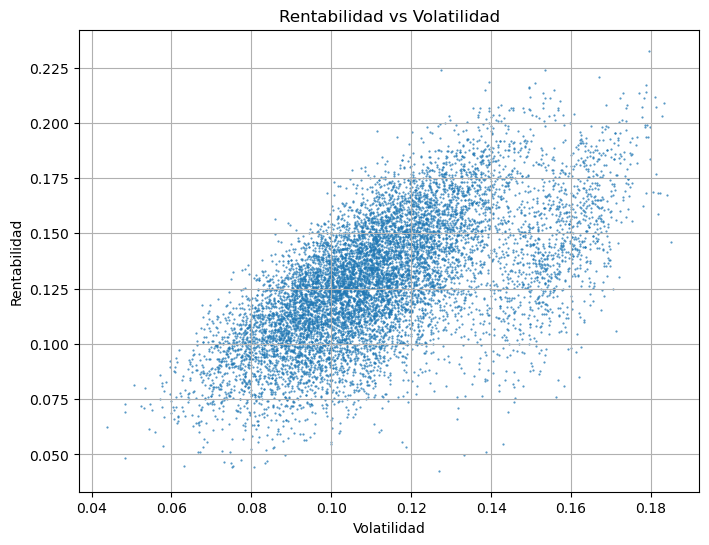

In [15]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6)) # tamaño

plt.scatter(df_carteras["vol"], df_carteras["rent"], alpha=0.8, s=0.3)

plt.xlabel("Volatilidad")
plt.ylabel("Rentabilidad")
plt.title("Rentabilidad vs Volatilidad")

plt.grid(True)
plt.show()   # mostrar gráfico

In [16]:
parametros = grafica_carteras(df_carteras)

In [17]:

print(parametros)

{'pendiente': np.float64(0.7909544488175696), 'intercepto': np.float64(3.9744249971626173), 'r2': np.float64(0.4027098305935458), 'correlacion': np.float64(0.6345942251498553)}


In [10]:
muestra(        df,        cartera,        rentabilidad,        volatilidad,        6125   )

Ticker,ETF,Categoría,Índice,Política,Bolsa,Moneda,Peso
XCS4.DE,Xtrackers MSCI Thailand UCITS ETF 1C,CHINA / INDIA,MSCI Thailand,Acc,Xetra,EUR,10.0%
XCS6.DE,Xtrackers MSCI China UCITS ETF 1C,CHINA / INDIA,MSCI China,Acc,Xetra,EUR,10.0%
IEAC.AS,iShares Core € Corp Bond UCITS ETF,BONOS / RENTA FIJA CORE,Euro Corp IG,N/D,Euronext Amsterdam,EUR,10.0%
XESP.DE,Xtrackers Spain UCITS ETF (Solactive Spain 40),PAÍSES (Europa),Solactive Spain 40,N/D,Xetra,EUR,10.0%
SXR0.DE,iShares Edge MSCI World Min Vol EUR Hedged UCITS ETF (Acc),FACTORES (WORLD),MSCI World Min Vol (EUR Hedged),Acc,Xetra,EUR,10.0%
EUNA.DE,iShares Core Global Aggregate Bond UCITS ETF EUR Hedged,BONOS / RENTA FIJA CORE,Global Aggregate (EUR Hedged),N/D,Xetra,EUR,10.0%
IQQC.DE,iShares China Large Cap UCITS ETF,CHINA / INDIA,China Large Cap,N/D,Xetra,EUR,10.0%
IQQ0.DE,iShares Edge MSCI World Min Vol UCITS ETF (Acc),FACTORES (WORLD),MSCI World Min Vol,Acc,Xetra,EUR,10.0%
VECP.AS,Vanguard EUR Corporate Bond UCITS ETF,BONOS / RENTA FIJA CORE,Euro Corp IG,N/D,Euronext Amsterdam,EUR,10.0%
IBGS.AS,iShares € Govt Bond 1-3yr UCITS ETF,BONOS / RENTA FIJA CORE,Euro Govt 1-3y,N/D,Euronext Amsterdam,EUR,10.0%
